# Using AI for Visualization
**BDSY 2026 · Big Data Summer Immersion · Friday, June 26, 2026 · 10:45 AM – 12:15 PM · Room 106A**

Welcome to the last morning of Week 2. By now you've **written Python** (Intro to
Python, Python I & II) and — just yesterday — built statistical graphics with
**ggplot2**. Today we connect those two threads:

- **seaborn is ggplot2's Python cousin.** Same instinct you used yesterday — hand
  it a tidy DataFrame, *map columns to visual properties*, get good defaults out —
  but it speaks pandas instead of R. (`aes(color=)` → `hue=`, `facet_wrap` → `col=`.)
- We use the data that ships **inside seaborn** — no files to upload.
- And we point an **AI coding assistant** at the plotting workflow. You already met
  this loop in *Coding with Claude* — **describe → generate → run → read the error →
  iterate**. **Use whatever AI you already have** — ChatGPT, Claude, Copilot — or
  **Gemini, built right into Google Colab** (nothing to install, it's already in the
  room). The skill is the loop, not the brand.

> **The rule for today: _AI drafts, you direct._** The assistant writes the code
> fast; *you* decide whether the figure is clear, honest, and makes the point. In
> public health a misleading chart isn't just ugly — it misinforms. So the last
> thing we practice is **verifying** what the AI hands you.

Run the setup cell next.

## ⚙️ Setup — run this cell first

In [1]:
# ===== SETUP — run this cell first! =====
import seaborn as sns
import matplotlib.pyplot as plt

# One line that makes EVERY plot look professional:
sns.set_theme(style="whitegrid", context="talk")

# seaborn ships with clean datasets — no files needed:
penguins = sns.load_dataset("penguins").dropna()
tips     = sns.load_dataset("tips")
flights  = sns.load_dataset("flights")
titanic  = sns.load_dataset("titanic")

print("Datasets loaded:")
for name, df in [("penguins", penguins), ("tips", tips),
                 ("flights", flights), ("titanic", titanic)]:
    print(f"  {name:9s} {df.shape}  ->  {list(df.columns)}")

penguins.head()

Datasets loaded:
  penguins  (333, 7)  ->  ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
  tips      (244, 7)  ->  ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
  flights   (144, 3)  ->  ['year', 'month', 'passengers']
  titanic   (891, 15)  ->  ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


---
# 1. Why seaborn? (~8 min)

Think of it this way: **matplotlib is the engine; seaborn is the smart layer on
top.** Seaborn talks to pandas DataFrames directly, does the statistics for you,
and looks good by default. It still *returns* matplotlib objects, so you can fine-
tune anything with `plt.title`, `figsize`, `plt.savefig`.

**Coming from ggplot2?** You'll feel at home. Yesterday you wrote
`ggplot(df, aes(x, y, color=group)) + geom_point()`. In seaborn that's
`sns.scatterplot(data=df, x=, y=, hue="group")` — same grammar-of-graphics idea
(map columns to aesthetics), Python syntax.

The "aha": this single line **groups by day, averages the bill, AND draws error
bars** — the seaborn equivalent of a `stat_summary` layer, in one call.

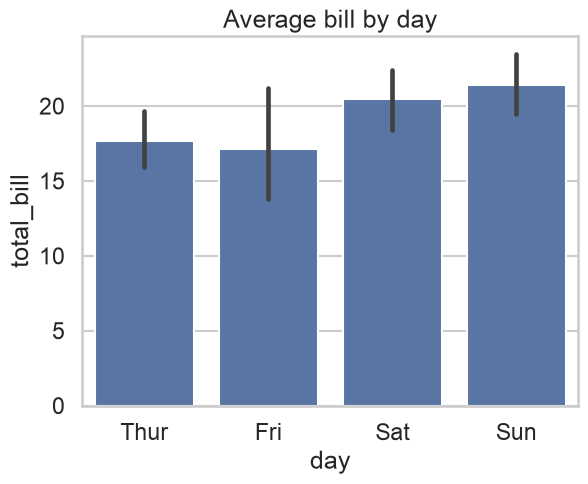

In [2]:
sns.barplot(data=tips, x="day", y="total_bill")
plt.title("Average bill by day")
plt.show()

**You write the *what*, not the *how*.** You name the DataFrame and which
columns go on x and y — seaborn handles the rest.

---
# 2. The three families of plots (~22 min)

Almost every seaborn plot belongs to one of three families, each answering a
different kind of question:

| Your question | Family | Functions |
|---|---|---|
| "How do two **numbers** relate?" | **Relational** | `scatterplot`, `lineplot` |
| "What's the **shape/spread** of a number?" | **Distribution** | `histplot`, `boxplot` |
| "How does a number **compare across categories**?" | **Categorical** | `barplot`, `countplot` |

Pick the family that matches your question — that's visualization principle #1.

### Relational — `scatterplot`: how do two numbers relate?

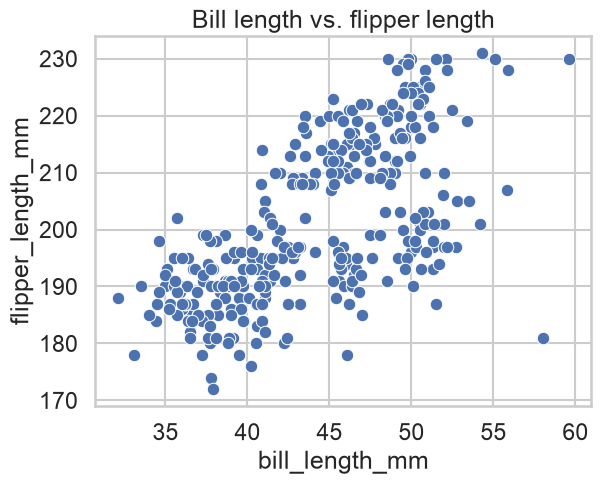

In [3]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="flipper_length_mm")
plt.title("Bill length vs. flipper length")
plt.show()

### Relational — `lineplot`: a trend over time (flights data)

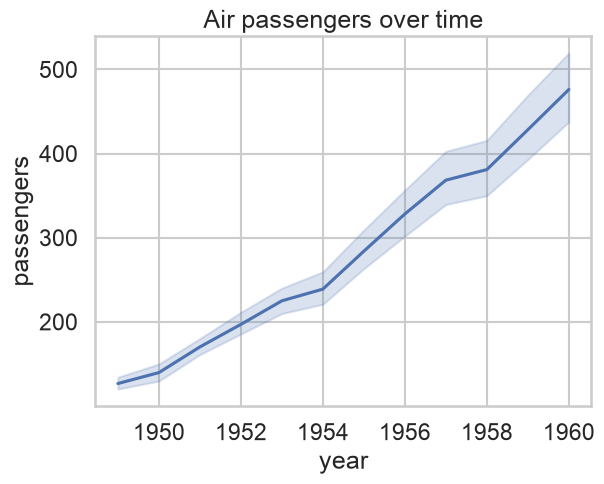

In [4]:
sns.lineplot(data=flights, x="year", y="passengers")
plt.title("Air passengers over time")
plt.show()

### Distribution — `histplot`: the shape/spread of one number

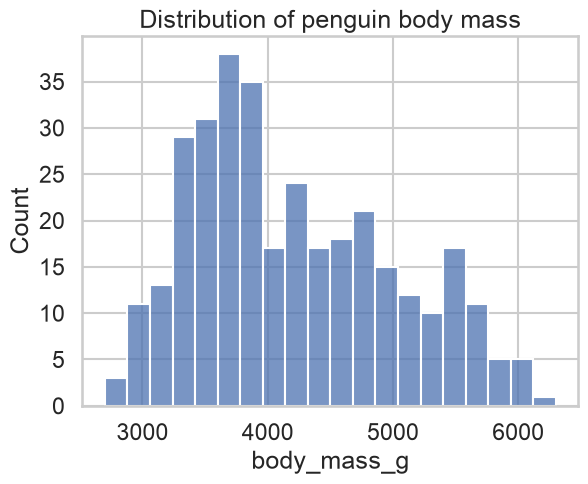

In [5]:
sns.histplot(data=penguins, x="body_mass_g", bins=20)
plt.title("Distribution of penguin body mass")
plt.show()

### Distribution — `boxplot`: spread of a number across categories

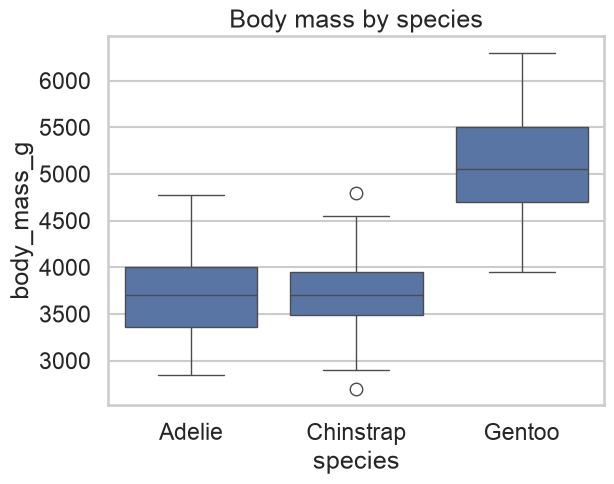

In [6]:
sns.boxplot(data=penguins, x="species", y="body_mass_g")
plt.title("Body mass by species")
plt.show()

### Categorical — `countplot`: how many rows in each category?

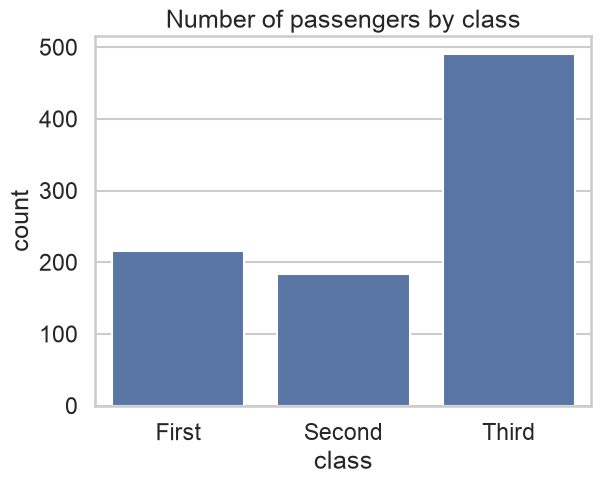

In [7]:
sns.countplot(data=titanic, x="class")
plt.title("Number of passengers by class")
plt.show()

> 🗣️ **Your turn (try it):** In the blank cell below, make a `barplot` of the
> average **tip** by **day** from the `tips` data. (Hint: copy the bar example
> from section 1 and change the columns.)

In [8]:
# Your turn — average tip by day:


---
# 3. Semantic mappings — seaborn's superpower (~12 min)

You can map a **column** to a **visual property** — exactly the `aes()` idea from
ggplot2. This lets one plot show many variables at once. The key keywords:

- `hue=`  → **color** (ggplot2 `color=`/`fill=`)
- `size=` → **dot/line size**
- `style=` → **marker shape**
- `col=` / `row=` → split into **separate side-by-side plots** (ggplot2 `facet_wrap`)

Watch what `hue="species"` does to our earlier scatter — the three species
separate into clear clouds:

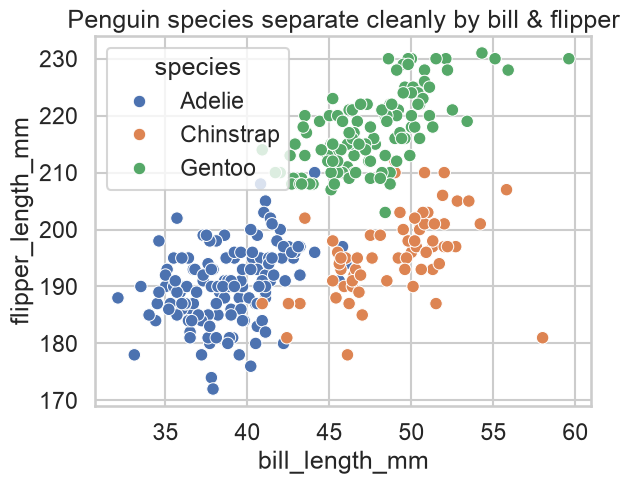

In [9]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species")
plt.title("Penguin species separate cleanly by bill & flipper")
plt.show()

> 👀 **Demo — watch, don't type.** The next three cells go fast; just follow
> along. You can come back and run them yourself afterward.

Layer in **two more variables** at once — `size` and `style`:

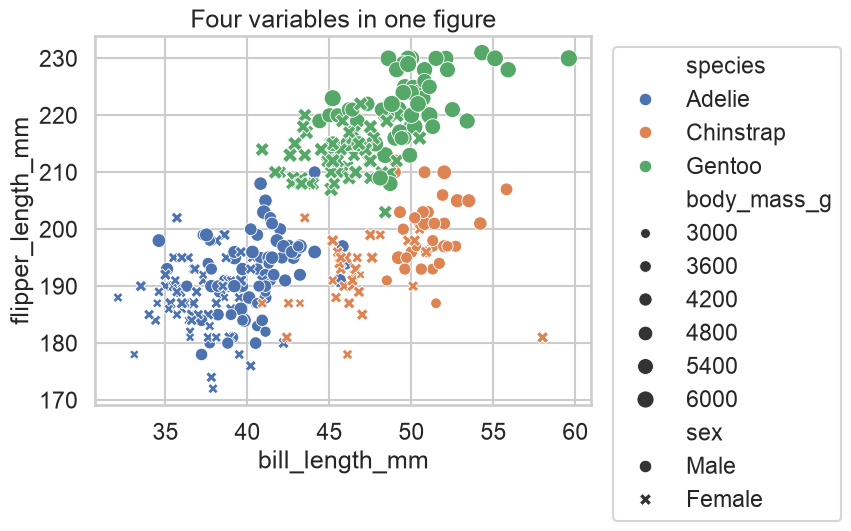

In [10]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", size="body_mass_g", style="sex")
plt.title("Four variables in one figure")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

**Small multiples** with `col=` splits the data into one panel per category —
this is ggplot2's `facet_wrap`. Note `relplot` is a **figure-level** function: it
makes its *own* figure, so you style it via the returned grid, not a trailing
`plt.title()`. (Same goes for `pairplot` and `catplot`.)

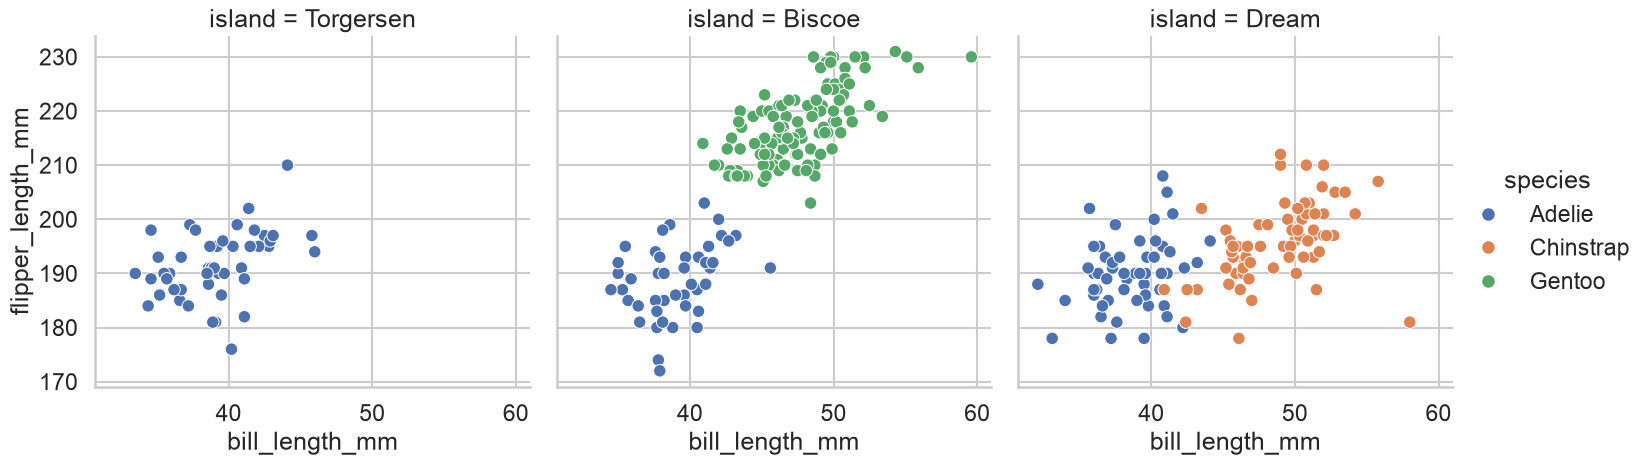

In [11]:
sns.relplot(data=penguins, x="bill_length_mm", y="flipper_length_mm",
            hue="species", col="island")
plt.show()

**`pairplot`** — instant overview: every numeric variable plotted against
every other. Great first look at any new dataset.

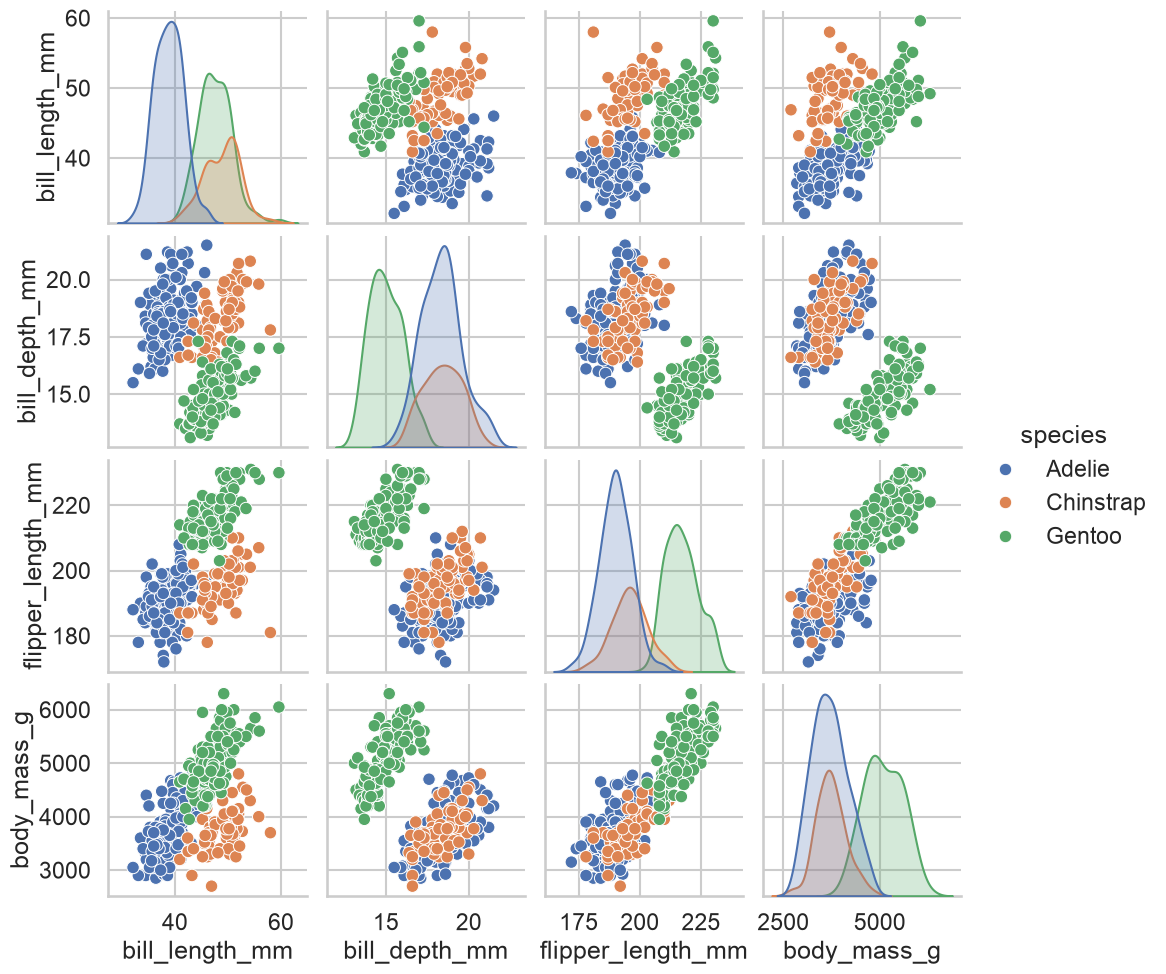

In [12]:
sns.pairplot(penguins, hue="species")
plt.show()

---
# 4. ★ Main hands-on: drive an AI coding assistant (~32 min)

This is the core of the workshop. You don't have to memorize seaborn — **describe
what you want, let the assistant draft the code, then run, read, and improve it.**

### The loop (you met it in *Coding with Claude*)
**describe → generate → run → read the output/error → refine.** It's the same loop
whether the assistant is Claude, ChatGPT, Copilot, or Gemini — what makes *you*
effective is a clear request and a critical eye on what comes back.

> **Use whatever AI you already have.** Got ChatGPT or Claude open in a browser
> tab? Use that — paste the prompt, copy the code back into a cell. No account
> handy? **Gemini is built right into Colab** (no separate login). Pick one and go;
> the prompts below work the same in any of them.

### Using Gemini inside Colab (one convenient option)
- Click **+ Generate** (or the Gemini ✨ icon) above a cell to describe a plot in
  plain English and get a code cell back.
- Select an existing code cell and ask Gemini to **improve / explain** it.
- If a cell errors, click **"Explain error"** — Gemini tells you what went wrong.

*Using ChatGPT/Claude in a browser tab instead?* Same idea — paste the prompt,
copy the code into a cell, and paste any error back to ask for a fix.

> **Don't see Gemini and don't have another AI handy?** No problem — every
> exercise below includes a worked answer you can expand and run, so you're never
> stuck waiting.

### A good visualization prompt has four parts
1. **Dataset & columns** — name the DataFrame and the columns to use.
2. **Goal** — the question / the takeaway.
3. **Constraints** — "use seaborn", colorblind-safe, one figure, add a title.
4. **Chart type** (optional) — if you already know it, say so.

### Copy this prompt into your AI
```
Using the pandas DataFrame `penguins` (columns: species, island,
bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, sex),
use seaborn to plot body_mass_g for each species as a boxplot, colored
by sex, with a colorblind-safe palette and a clear title. Return only code.
```

**Paste the AI's code below and run it.** Did it work first try? If it errors, use *Explain error* (or paste the error back to your AI) and try again.

In [13]:
# Paste the AI's generated code here, then run:



> 👉 **Stuck / no AI?** Expand-and-run this worked answer (try the prompt first):

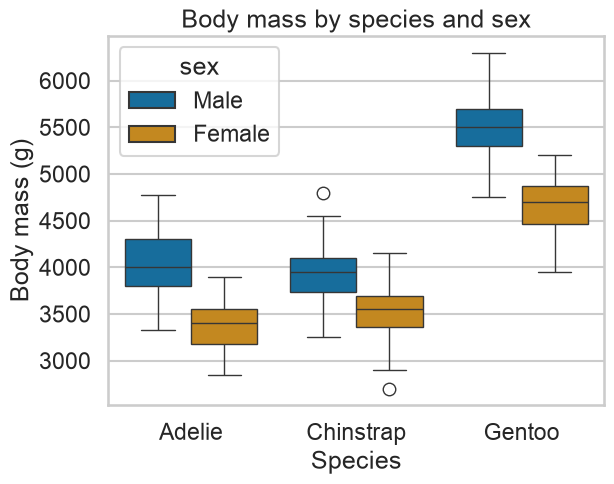

In [14]:
# Worked answer for the boxplot prompt above:
sns.boxplot(data=penguins, x="species", y="body_mass_g", hue="sex",
            palette="colorblind")
plt.title("Body mass by species and sex")
plt.xlabel("Species"); plt.ylabel("Body mass (g)")
plt.show()

### Exercise A — ask the AI for a brand-new plot
Pick one question, turn it into a 4-part prompt, and paste the code it gives back:
- *"Average tip by day of week, split by lunch vs. dinner."* (`tips`)
- *"Survival rate by passenger class."* (`titanic`)
- *"Passengers per month across years as a heatmap."* (`flights`, needs a pivot)
- *"How tip relates to total bill, colored by whether the party smoked."* (`tips`)
- *"Distribution of penguin body mass for each species, as overlapping curves."* (`penguins`)

In [15]:
# Your AI-built plot here:



> 👉 **Stuck / no AI?** A worked answer for the survival-rate option:

/var/folders/jb/ygj76rvj56g2v4w402nvw96m0000gp/T/ipykernel_27160/1484951665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x="class", y="survived", palette="colorblind")


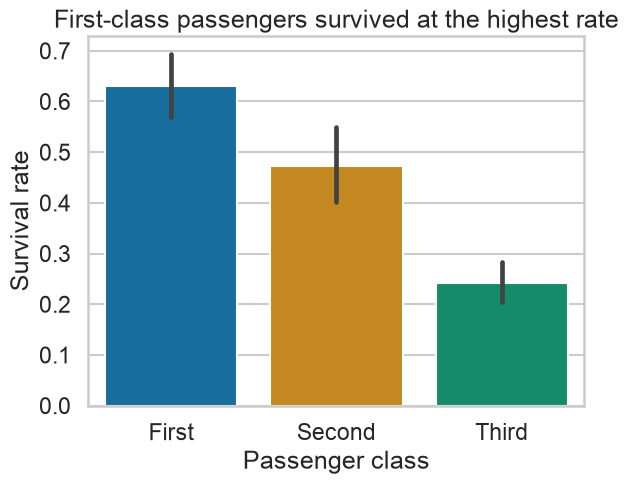

In [16]:
# Survival rate by passenger class (titanic):
sns.barplot(data=titanic, x="class", y="survived", palette="colorblind")
plt.title("First-class passengers survived at the highest rate")
plt.xlabel("Passenger class"); plt.ylabel("Survival rate")
plt.show()

### Exercise B — "make it better"
Here's a working-but-ugly plot. Select it in Colab (or copy it into your AI) and ask:
> *"Make this chart presentation-ready: clean theme, colorblind-safe palette, a
> title that states the takeaway, labeled axes with units, bigger fonts."*

Then paste the improved version in the next cell and compare.

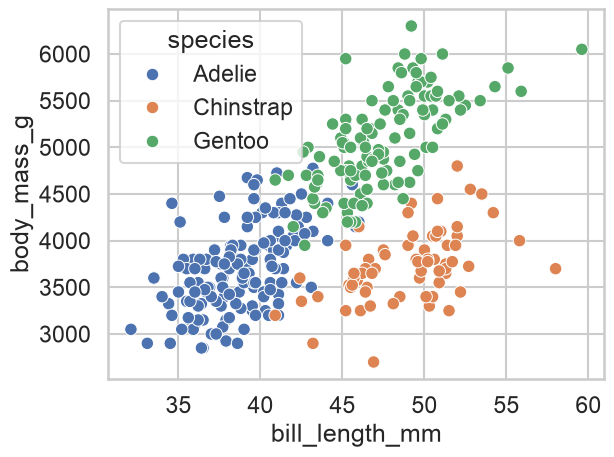

In [17]:
# BEFORE (works, but bland):
sns.scatterplot(data=penguins, x="bill_length_mm", y="body_mass_g", hue="species")
plt.show()

In [18]:
# AFTER — paste the AI's improved version here:



> 👉 **Stuck / no AI?** One presentation-ready version of the plot above:

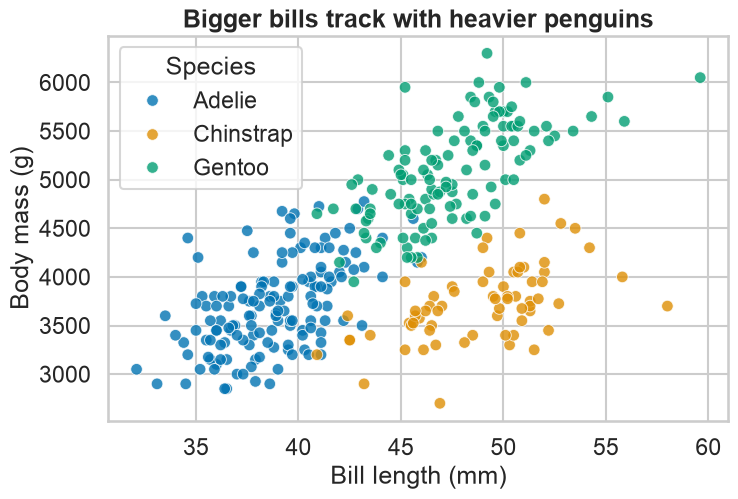

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=penguins, x="bill_length_mm", y="body_mass_g",
                hue="species", palette="colorblind", s=70, alpha=0.8, ax=ax)
ax.set_title("Bigger bills track with heavier penguins", weight="bold")
ax.set_xlabel("Bill length (mm)"); ax.set_ylabel("Body mass (g)")
ax.legend(title="Species")
plt.show()

### Exercise C — make the AI go *further* (stretch)
So far the AI has *drafted* and *prettied up* plots. It can also help you find the
*right* chart and add insight you'd otherwise hand-code. If you have time, try one:

- **AI as advisor:** *"I want to show how penguin body mass differs across the three
  species. What chart type best shows this, and why? Then give me the seaborn code."*
- **Add a trend line:** *"Add a regression/trend line to a seaborn scatter of
  bill_length_mm vs. body_mass_g in the `penguins` data."*
- **Annotate the takeaway:** *"Make a seaborn barplot of survival rate by class
  (`titanic`) and print the value on top of each bar."*

Notice the AI isn't just typing for you — it's helping you *decide* and *add
meaning*. You still judge whether its advice is right.

In [20]:
# Your "go further" plot here:



> 👉 **Stuck / no AI?** A worked answer for the *annotate the takeaway* option:

/var/folders/jb/ygj76rvj56g2v4w402nvw96m0000gp/T/ipykernel_27160/159590961.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=titanic, x="class", y="survived", palette="colorblind")


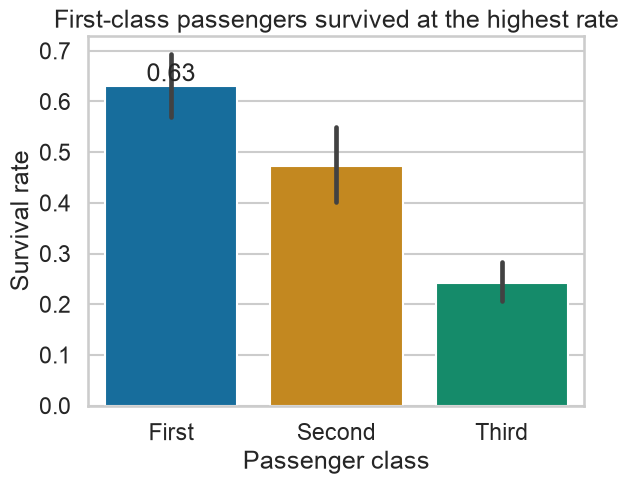

In [21]:
ax = sns.barplot(data=titanic, x="class", y="survived", palette="colorblind")
ax.bar_label(ax.containers[0], fmt="%.2f")          # value on top of each bar
ax.set_title("First-class passengers survived at the highest rate")
ax.set_xlabel("Passenger class"); ax.set_ylabel("Survival rate")
plt.show()

### Exercise D — catch the hallucination
AI doesn't usually fail with obvious gibberish. The dangerous failures are
**plausible** — it borrows a feature from a *different* library and writes code
that looks completely reasonable. The cell below is exactly that: the AI tried to
add a trend line with `trendline="ols"` — that's a **Plotly** argument; seaborn's
`scatterplot` has no such option, so it errors.

Your job, not the AI's: run it as-is, read the error (try *Explain error*), and
**fix it in the next cell** — the *real* seaborn way to get a trend line is
`sns.regplot`. (Worth knowing: an even sneakier hallucination is code that *runs*
but quietly plots the wrong thing — that's why §5 is all about verifying.)

AttributeError: PathCollection.set() got an unexpected keyword argument 'trendline'

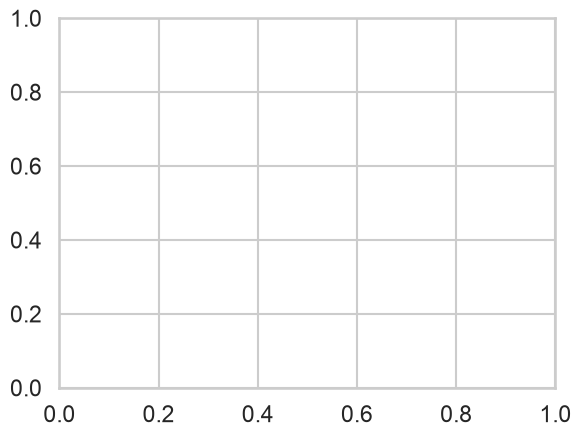

In [22]:
# RUN THIS — it will error on purpose (trendline= is not a seaborn argument):
sns.scatterplot(data=penguins, x="bill_length_mm", y="body_mass_g", trendline="ols")
plt.title("Bill length vs. body mass")
plt.show()

**Your fix below** — get a real trend line with `sns.regplot`, and add honest labels:

In [23]:
# Fix the broken call above:



> 👉 Worked answer:

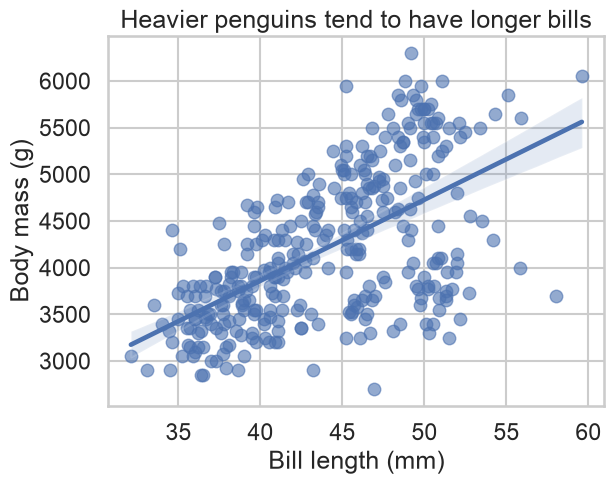

In [24]:
sns.regplot(data=penguins, x="bill_length_mm", y="body_mass_g",
            scatter_kws={"alpha": 0.6})
plt.title("Heavier penguins tend to have longer bills")
plt.xlabel("Bill length (mm)"); plt.ylabel("Body mass (g)")
plt.show()

---
# 5. Polish, principles & verification (~13 min)

A plot that *runs* is not the same as a plot that's *ready to present*. Five
principles, each a small seaborn choice:

1. **Right chart** → pick the matching family (you did this in §2).
2. **Reduce clutter** → `sns.set_theme(style="whitegrid")` (already on).
3. **Color with intent** → `palette="colorblind"`; use `hue` for real categories.
4. **Label to stand alone** → a *takeaway* title, axis labels **with units**.
5. **Don't mislead** → honest axes and aggregation.

Here's the same penguin scatter, polished and exported for slides:

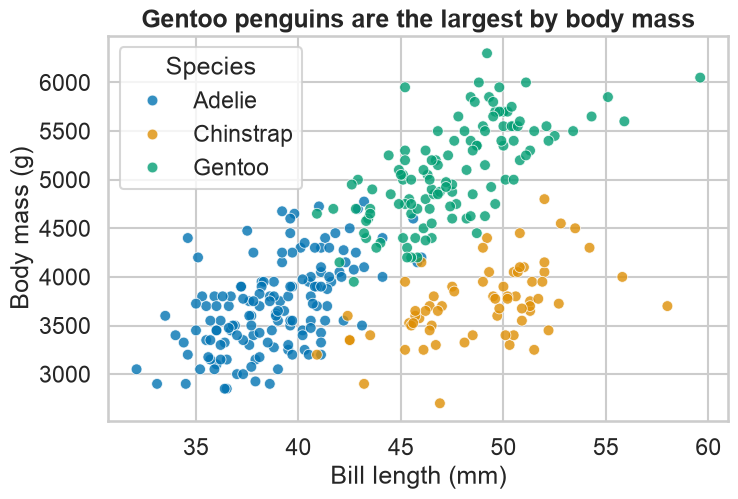

Saved penguins_polished.png — drop it into your slides or report.


In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=penguins, x="bill_length_mm", y="body_mass_g",
                hue="species", palette="colorblind", s=60, alpha=0.8, ax=ax)
ax.set_title("Gentoo penguins are the largest by body mass", weight="bold")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Body mass (g)")
ax.legend(title="Species")
fig.savefig("penguins_polished.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved penguins_polished.png — drop it into your slides or report.")

### ✅ Trust-this-figure checklist (before you believe any AI plot)
- [ ] The code runs and uses **real** seaborn functions/arguments (no `trendline=`
      borrowed from another library).
- [ ] The **chart type matches the question** (right family).
- [ ] **Axes, units, and the title** are correct and honest.
- [ ] The **numbers match the data** — spot-check one value.
- [ ] A stranger could read it **without you explaining it**.

Quick verify — does the figure's story match the raw numbers?

In [26]:
print(penguins.groupby("species")["body_mass_g"].mean().round(0))

species
Adelie       3706.0
Chinstrap    3733.0
Gentoo       5092.0
Name: body_mass_g, dtype: float64


---
## Where to go from here
- These skills carry straight into your later Python & ML courses (loss curves,
  confusion matrices, feature distributions — all seaborn).
- See the `README.md` for a resource list (seaborn tutorial, Data-to-Viz,
  ColorBrewer).
- Keep a personal **prompt library** of the viz prompts that worked for you.

🎉 **Nice work!** You used seaborn for real plots, drove an AI assistant to draft and
improve them, and learned to verify before you trust.